In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import json
import seaborn as sns
import warnings
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=UserWarning)


sys.path.append("/home/iscb/wolfson/hagairavid/LocAlign")
from utils.loading import deserialize_nested_lists

In [3]:
import os
import pandas as pd
import json

# Configuration
prefix = "2024-12-25_11-20"  # Update as needed
prefix = "2024-12-26_17-28"
prefix = "2024-12-26_17-42"
prefix = "2024-12-31_10-39"
prefix = "2024-12-31_11-09"
prefix = "2024-12-31_11-28"
directory = "/home/iscb/wolfson/hagairavid/LocAlign/results/alignment_temp_results/"

# Find the latest matching file
matching_files = [f for f in os.listdir(directory) if f.startswith(prefix)]
if matching_files:
    latest_file = max(matching_files, key=lambda x: os.path.getmtime(os.path.join(directory, x)))
    file_path = os.path.join(directory, latest_file)
    print("Latest file:", file_path)
else:
    print("No matching files found.")
    exit()

# Read the CSV file
df = pd.read_csv(file_path)

# Convert 'coverage' and 'rmse' columns to string
df['coverage'] = df['coverage'].astype(str)
df['rmse'] = df['rmse'].astype(str)

# Process columns with JSON-like strings
def safe_json_load(value, column_name):
    if isinstance(value, str) and value.startswith('[') and value.endswith(']'):
        try:
            return json.loads(value)
        except json.JSONDecodeError:
            print(f"Invalid JSON in column '{column_name}': {value}")
            return value
    return value

for col in df.columns:
    # Apply JSON parsing only for columns with potential JSON strings
    if df[col].apply(lambda x: isinstance(x, str) and x.startswith('[') and x.endswith(']')).any():
        df[col] = df[col].apply(lambda x: safe_json_load(x, col))

# Apply deserialization to relevant columns
for col in df.columns:
    df[col] = df[col].apply(lambda x: deserialize_nested_lists(x, col) if isinstance(x, list) else x)

# Print or process the dataframe as needed
print(df)


Latest file: /home/iscb/wolfson/hagairavid/LocAlign/results/alignment_temp_results/2024-12-31_11-28-50_2000_7_ang_1_ang.csv
     Ligand_ID ref_protein mov_protein ref_chain mov_chain  n_transformations  \
0          SFG        2yxl        3lkz         A         A                  1   
1          MAN        1ly8        3fjw         A         A                  3   
2          ANP        3aln        3qf7         A         A                  1   
3          AKG        1ds1        2rdn         A         A                  1   
4          FMN        1bwk        5j62         A         B                  1   
...        ...         ...         ...       ...       ...                ...   
1995       TPP        1ay0        5hht         A         B                  1   
1996       TYD        1epz        4lei         A         A                  1   
1997       GSH        4hoj        5hfk         A         A                  2   
1998       C2E        4lj3        5mf5         A         A        

In [4]:
with_trans = df[df['n_transformations'] > 0]
with_trans.columns

Index(['Ligand_ID', 'ref_protein', 'mov_protein', 'ref_chain', 'mov_chain',
       'n_transformations', 'rotations', 'translations', 'rmse', 'coverage',
       'bbr', 'bbc', 'cath_degree', 'ref_ligand_n_atoms', 'mov_ligand_n_atoms',
       'n_residues_ref_ligand', 'n_residues_mov_ligand', 'failure_message',
       'TMAligner_rotations', 'TMAligner_translations',
       'TMAligner_protein_rmsd', 'TMAligner_rmsd', 'TMAligner_bbr',
       'TMAligner_bbc'],
      dtype='object')

/tmp/ipykernel_316308/822001947.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['max_bbr'] = with_trans['bbr'].apply(find_max_in_sublists)
/tmp/ipykernel_316308/822001947.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_trans['max_bbc'] = with_trans['bbc'].apply(find_max_in_sublists)
/tmp/ipykernel_316308/822001947.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

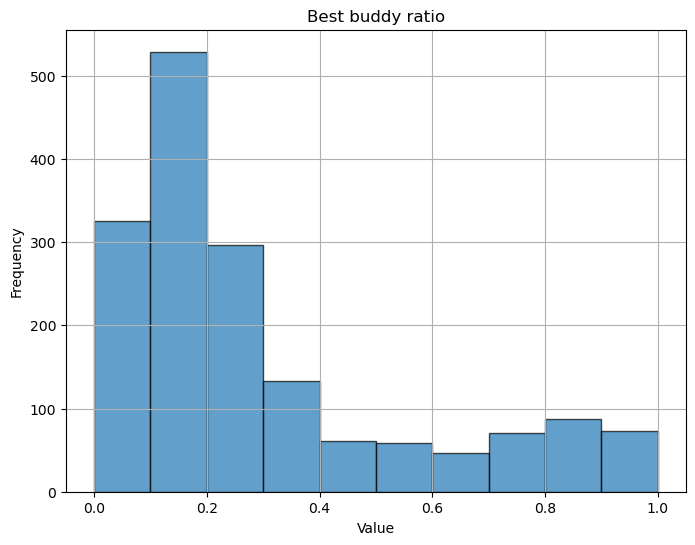

In [ ]:
def find_max_in_sublists(list_of_lists):
    try:
        return max([max(sublist) for sublist in list_of_lists])
    except:
        0

# Apply the function to the 'data' column and create a new column 'min_values'
with_trans['max_bbr'] = with_trans['bbr'].apply(find_max_in_sublists)
with_trans['max_bbc'] = with_trans['bbc'].apply(find_max_in_sublists)
with_trans['max_TMAligner_bbr'] = with_trans['TMAligner_bbr'].apply(find_max_in_sublists)
with_trans['max_TMAligner_bbc'] = with_trans['TMAligner_bbc'].apply(find_max_in_sublists)
plt.figure(figsize=(8, 6))


/tmp/ipykernel_316308/2082111150.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=with_trans, x='cath_degree', y='max_bbc', alpha=0.7, palette='coolwarm')


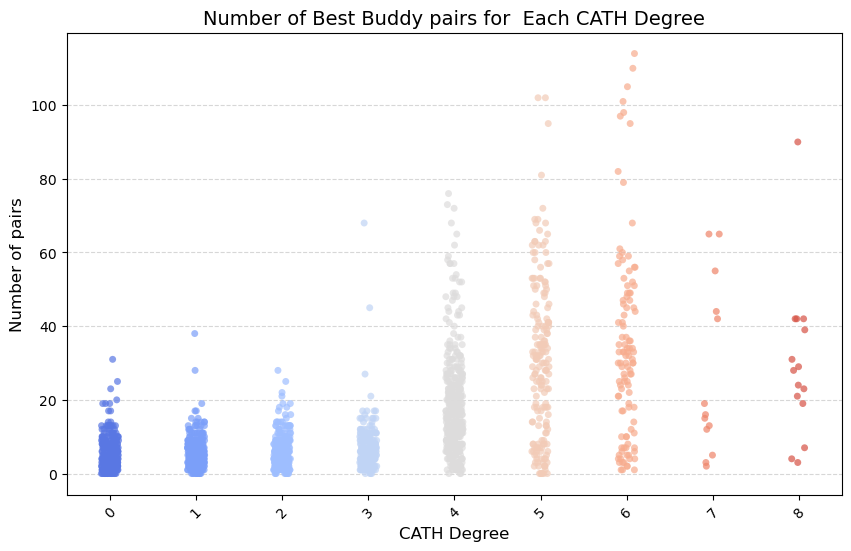

In [14]:
# Assuming `with_trans` is a pandas DataFrame containing 'max_bbr' and 'CATH_degree'
plt.figure(figsize=(10, 6))
sns.stripplot(data=with_trans, x='cath_degree', y='max_bbc', alpha=0.7, palette='coolwarm')
plt.title('Number of Best Buddy pairs for  Each CATH Degree', fontsize=14)
plt.xlabel('CATH Degree', fontsize=12)
plt.ylabel('Number of pairs', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.show()


/tmp/ipykernel_316308/446441127.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=with_trans, x='cath_degree', y='max_bbr', alpha=0.7, palette='viridis')


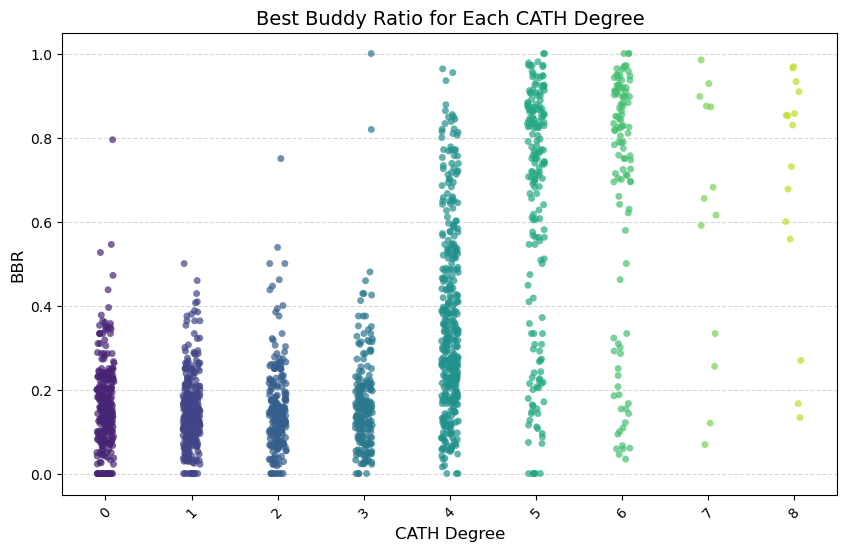

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming `with_trans` is a pandas DataFrame containing 'max_bbr' and 'CATH_degree'
plt.figure(figsize=(10, 6))
sns.stripplot(data=with_trans, x='cath_degree', y='max_bbr', alpha=0.7, palette='viridis')
plt.title('Best Buddy Ratio for Each CATH Degree', fontsize=14)
plt.xlabel('CATH Degree', fontsize=12)
plt.ylabel('BBR', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.show()


In [6]:
# with_trans[with_trans['max_bbr'] > 1.5].shape 
with_trans.shape

(1711, 28)

/tmp/ipykernel_316308/1352666133.py:35: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


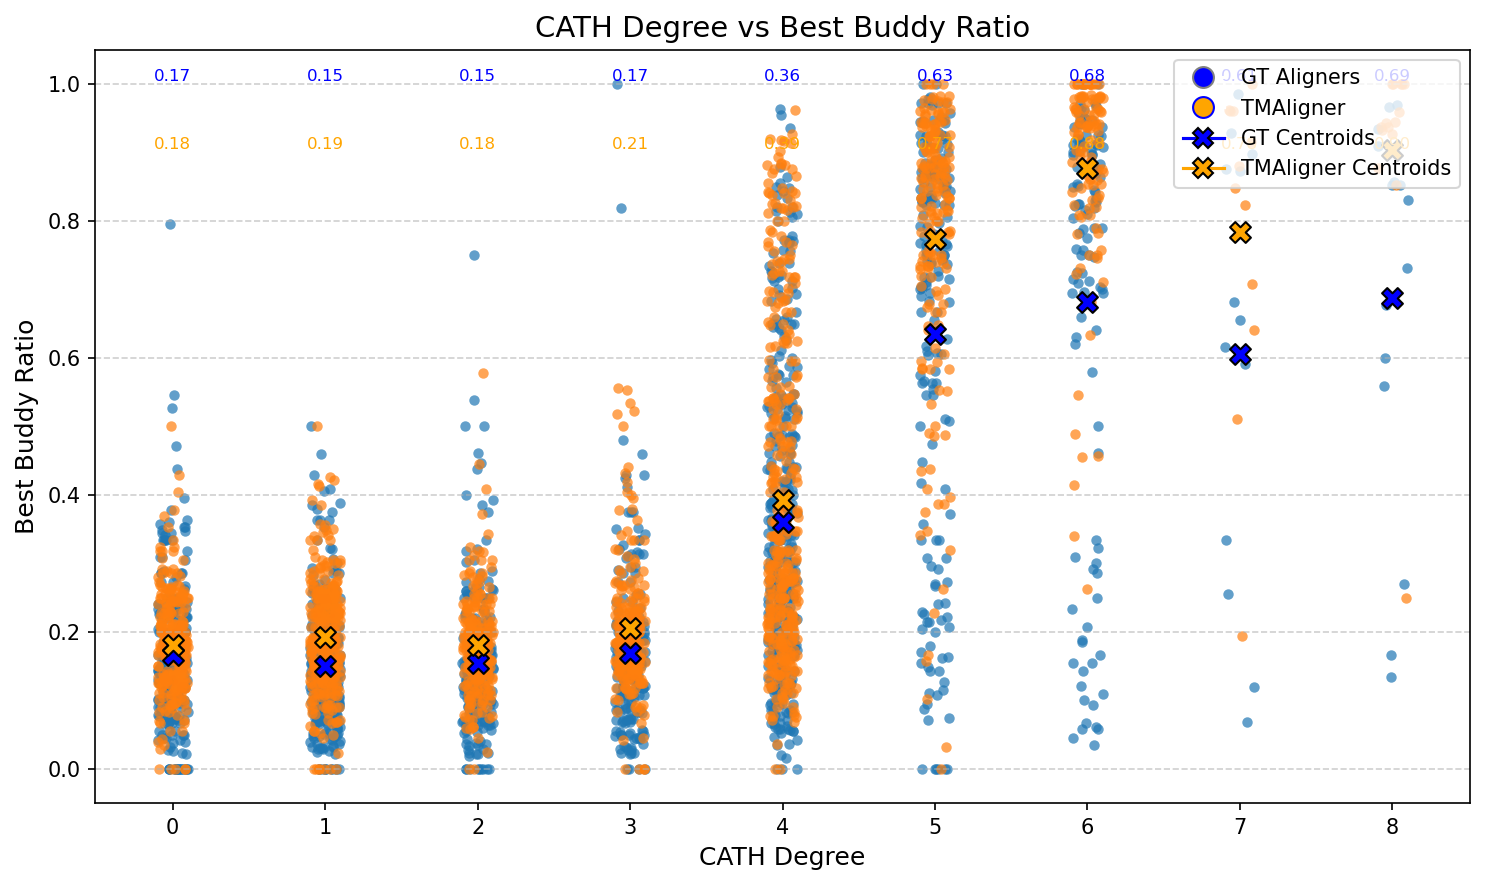

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# with_trans = with_trans.sample(2000)
# with_trans = with_trans[with_trans['max_bbc'] > 10]
# Function to plot centroids with labels
def plot_centroids(data, group_col, value_col, color, marker, label, zorder, medain_height=1):
    centroids = data.groupby(group_col)[value_col].mean().reset_index()
    plt.scatter(
        x=centroids[group_col],
        y=centroids[value_col],
        c=color,
        edgecolors='black',
        s=100,
        marker=marker,
        label=label,
        zorder=zorder,
    )
    # Add labels to each centroid
    for _, row in centroids.iterrows():
        plt.text(
            row[group_col], 
            medain_height, 
            f"{row[value_col]:.2f}",  # Format the value to 2 decimal places
            fontsize=8, 
            ha='center', 
            va='bottom', 
            color=color,
        )

# Set plot size and resolution
plt.figure(figsize=(10, 6), dpi=150)

# Create the strip plots
sns.stripplot(
    data=with_trans,
    x='cath_degree',
    y='max_bbr',
    jitter=True,
    alpha=0.7,
    size=5,
    edgecolor='gray',
    zorder=1,
    label='GT Aligners',
)
sns.stripplot(
    data=with_trans,
    x='cath_degree',
    y='max_TMAligner_bbr',
    jitter=True,
    alpha=0.7,
    size=5,
    edgecolor='blue',
    zorder=1,
    label='TMAligner',
)

# Overlay centroids with labels
plot_centroids(
    data=with_trans,
    group_col='cath_degree',
    value_col='max_bbr',
    color='blue',
    marker='X',
    label='GT Centroids',
    zorder=2,
)
plot_centroids(
    data=with_trans,
    group_col='cath_degree',
    value_col='max_TMAligner_bbr',
    color='orange',
    marker='X',
    label='TMAligner Centroids',
    zorder=2,
    medain_height=0.9,
)

# Add a custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='white', label='GT Aligners', markerfacecolor='blue', markersize=10, markeredgecolor='gray'),
    Line2D([0], [0], marker='o', color='white', label='TMAligner', markerfacecolor='orange', markersize=10, markeredgecolor='blue'),
    Line2D([0], [0], marker='X', color='blue', label='GT Centroids', markersize=10, markeredgecolor='black', markerfacecolor='blue'),
    Line2D([0], [0], marker='X', color='orange', label='TMAligner Centroids', markersize=10, markeredgecolor='black', markerfacecolor='orange'),
]
plt.legend(handles=legend_elements, fontsize=10, loc='upper right')

# Add plot details
plt.title('CATH Degree vs Best Buddy Ratio', fontsize=14)
plt.xlabel('CATH Degree', fontsize=12)
plt.ylabel('Best Buddy Ratio', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Show plot
plt.show()


/tmp/ipykernel_316308/618939363.py:33: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


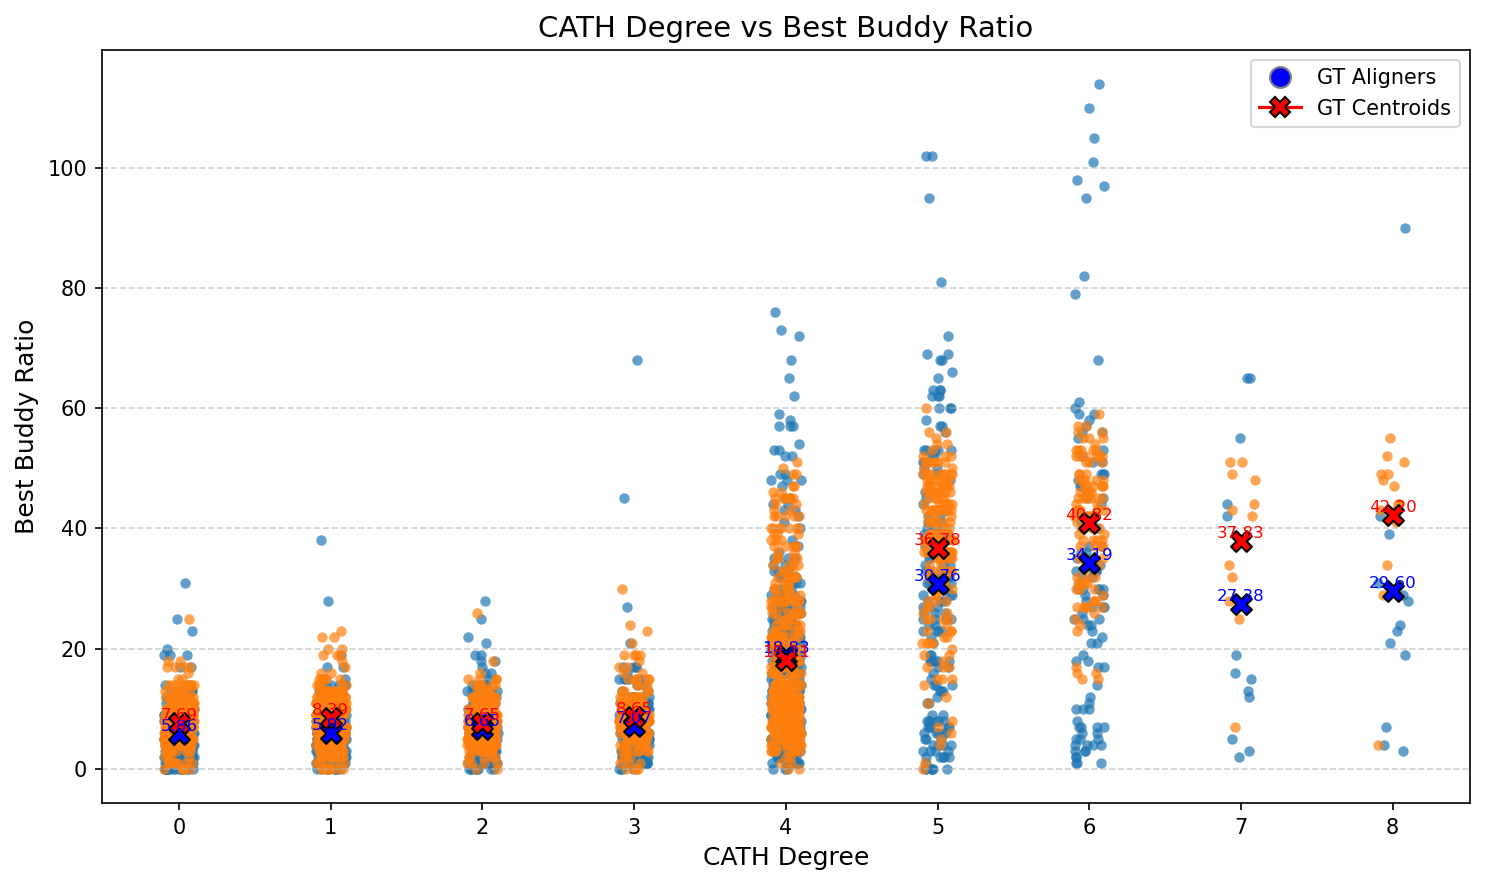

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# Function to plot centroids with labels
def plot_centroids(data, group_col, value_col, color, marker, label, zorder):
    centroids = data.groupby(group_col)[value_col].mean().reset_index()
    plt.scatter(
        x=centroids[group_col],
        y=centroids[value_col],
        c=color,
        edgecolors='black',
        s=100,
        marker=marker,
        label=label,
        zorder=zorder,
    )
    # Add labels to each centroid
    for _, row in centroids.iterrows():
        plt.text(
            row[group_col], 
            row[value_col], 
            f"{row[value_col]:.2f}",  # Format the value to 2 decimal places
            fontsize=8, 
            ha='center', 
            va='bottom', 
            color=color,
        )

# Set plot size and resolution
plt.figure(figsize=(10, 6), dpi=150)

# Create the strip plots
sns.stripplot(
    data=with_trans,
    x='cath_degree',
    y='max_bbc',
    jitter=True,
    alpha=0.7,
    size=5,
    edgecolor='gray',
    zorder=1,
    label='GT Aligners',
)
sns.stripplot(
    data=with_trans,
    x='cath_degree',
    y='max_TMAligner_bbc',
    jitter=True,
    alpha=0.7,
    size=5,
    edgecolor='blue',
    zorder=1,
    label='TMAligner',
)

# Overlay centroids with labels
plot_centroids(
    data=with_trans,
    group_col='cath_degree',
    value_col='max_bbc',
    color='blue',
    marker='X',
    label='GT Centroids',
    zorder=2,
)
plot_centroids(
    data=with_trans,
    group_col='cath_degree',
    value_col='max_TMAligner_bbc',
    color='red',
    marker='X',
    label='TMAligner Centroids',
    zorder=2,
)

# Add a custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='white', label='GT Aligners', markerfacecolor='blue', markersize=10, markeredgecolor='gray'),
    # Line2D([0], [0], marker='o', color='white', label='TMAligner', markerfacecolor='orange', markersize=10, markeredgecolor='blue'),
    Line2D([0], [0], marker='X', color='red', label='GT Centroids', markersize=10, markeredgecolor='black', markerfacecolor='red'),
    # Line2D([0], [0], marker='X', color='blue', label='TMAligner Centroids', markersize=10, markeredgecolor='black', markerfacecolor='blue'),
]
plt.legend(handles=legend_elements, fontsize=10, loc='upper right')

# Add plot details
plt.title('CATH Degree vs Best Buddy Ratio', fontsize=14)
plt.xlabel('CATH Degree', fontsize=12)
plt.ylabel('Best Buddy Ratio', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Show plot
plt.show()
